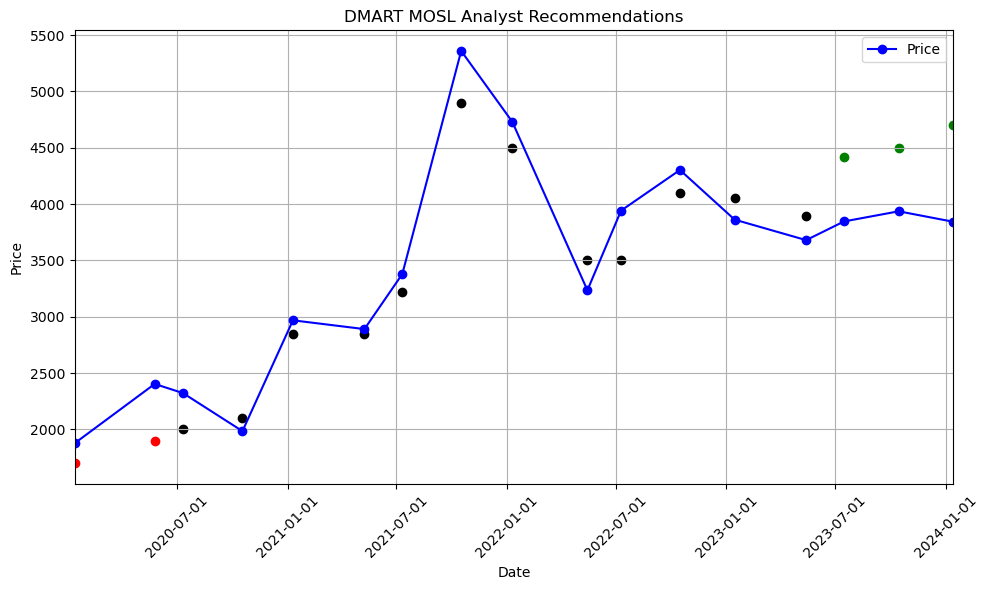

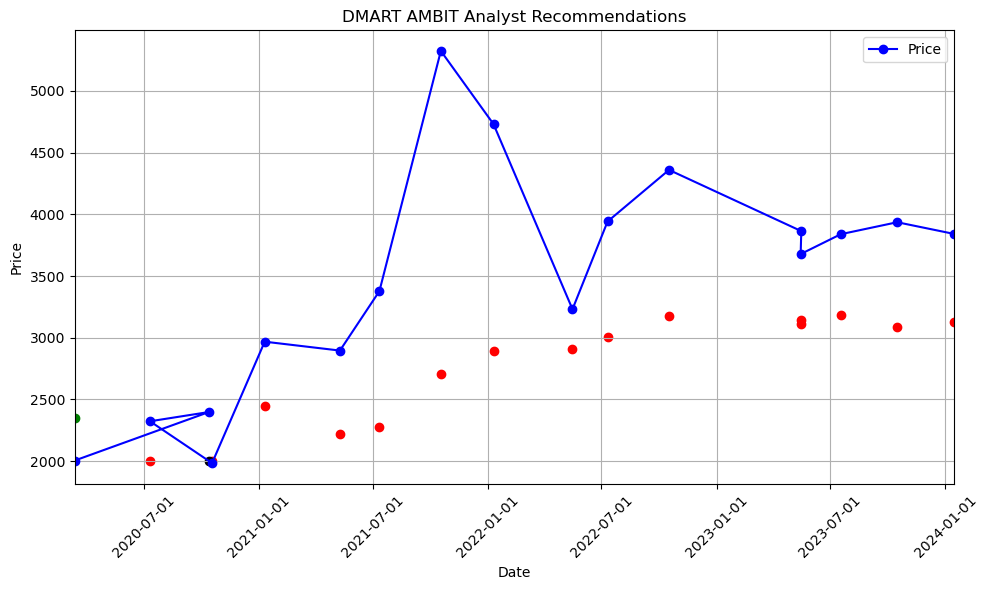

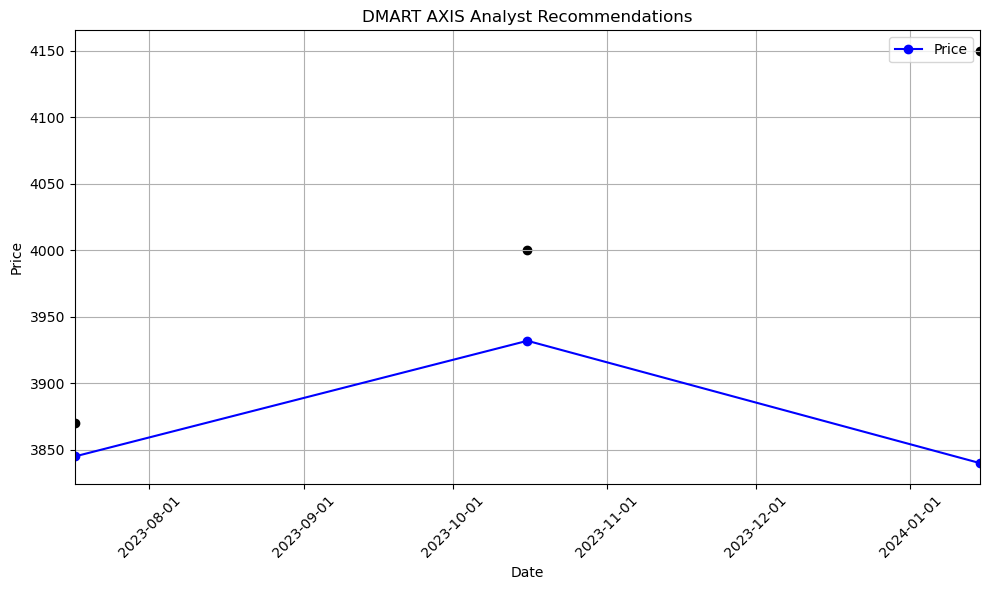

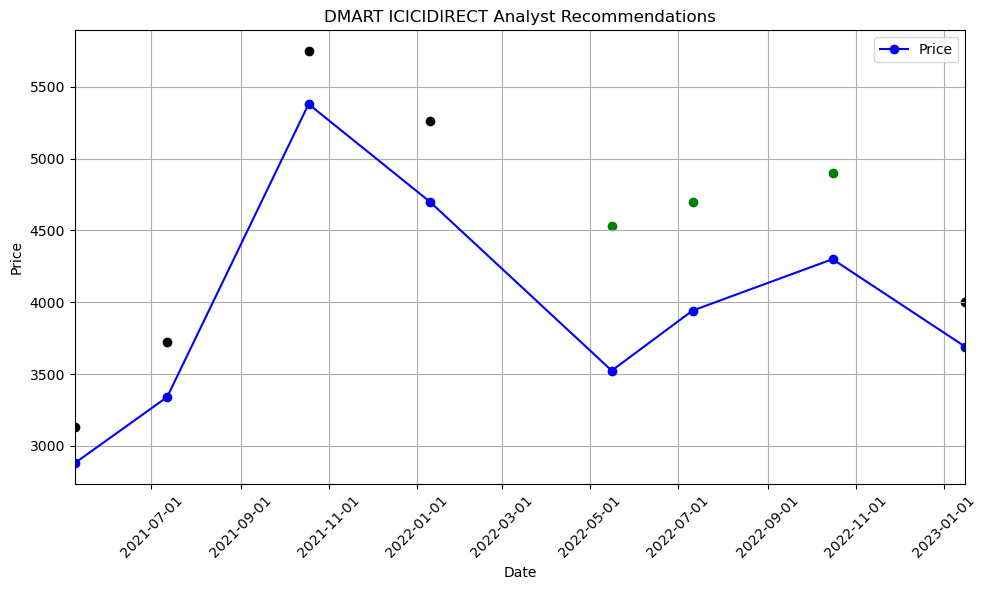

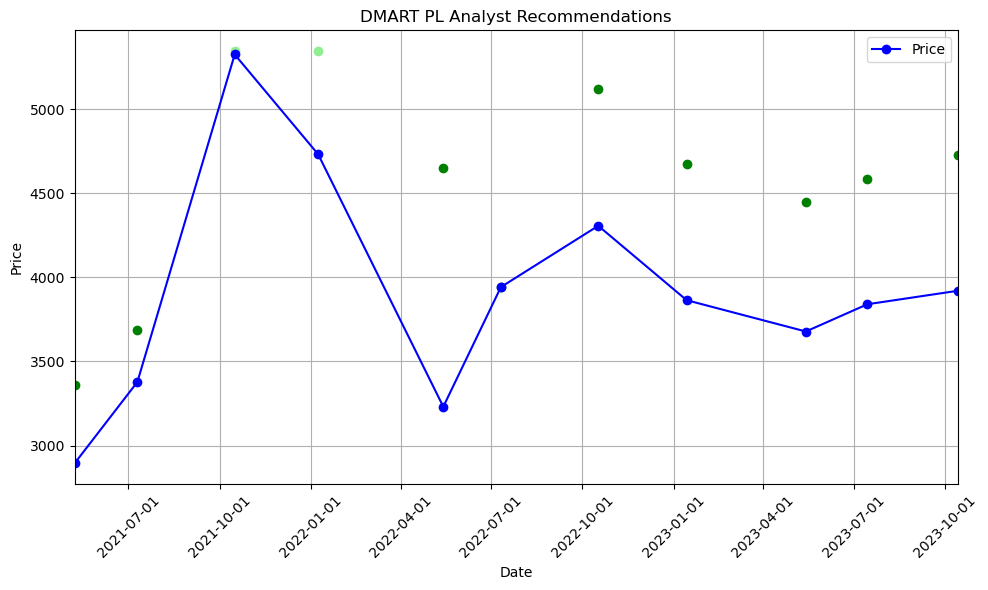

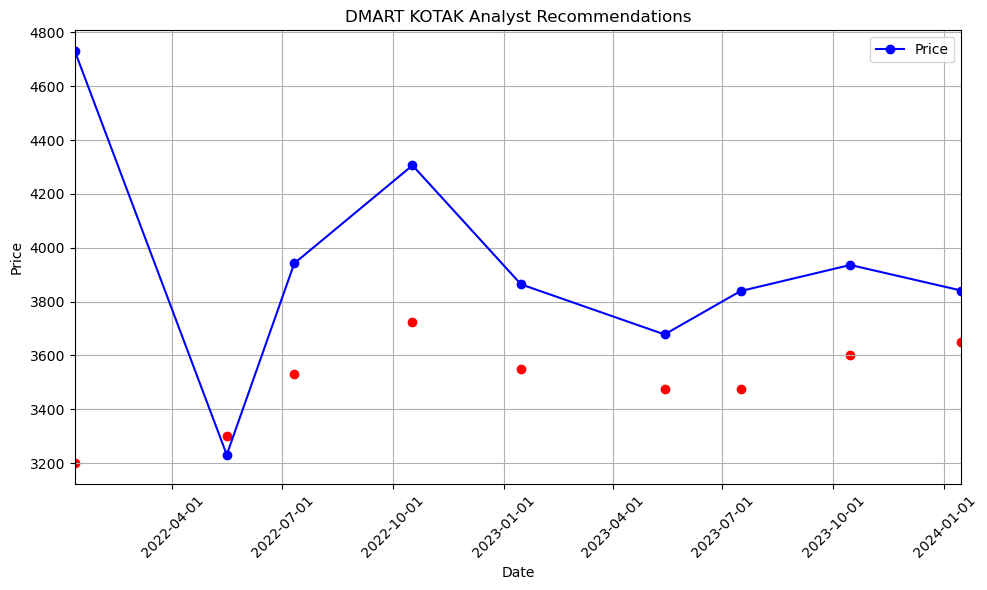

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Define the file path and ticker
ticker1 = 'DMART'
file_path_ticker1 = r'C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\QuarterResultsScreenerExcels\2025Q1\{}_FY25Q1.xlsx'.format(ticker1)

# Read the Excel file into a dataframe for ticker1
df_ticker1 = pd.read_excel(file_path_ticker1, sheet_name='AnalystReco')

# Broker labels
broker_labels = ['MOSL', 'AMBIT', 'AXIS', 'ICICIDIRECT', 'PL', 'KOTAK']

# Define the segments for each broker
segments = {
    'MOSL': (2, 21),
    'AMBIT': (22, 41),
    'AXIS': (42, 61),
    'ICICIDIRECT': (62, 81),
    'PL': (82, 101),
    'KOTAK': (102, 121)
}

# Loop through each broker and plot the data
for broker_label in broker_labels:
    # Get the segment range for the current broker
    start_row, end_row = segments[broker_label]
    start_row -= 2  # Adjusting the start_row index
    end_row -= 2    # Adjusting the end_row index
    
    # Filter the data for the current broker segment
    broker_data = df_ticker1[(df_ticker1['Broker'] == broker_label) & (df_ticker1.index >= start_row) & (df_ticker1.index <= end_row)]
    
    # Check if the required columns are present
    if 'Date' not in broker_data.columns or 'Price' not in broker_data.columns or 'Reco' not in broker_data.columns or 'Target' not in broker_data.columns:
        print(f"Required columns not found for {broker_label}")
        continue
    
    # Extract relevant columns
    dates = broker_data['Date']
    prices = broker_data['Price']
    reco = broker_data['Reco']
    targets = broker_data['Target']
    
    # Convert date strings to datetime objects
    dates = pd.to_datetime(dates, errors='coerce')
    
    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(dates, prices, label='Price', marker='o', color='blue')
    
    # Scatter plot for target prices
    for i, target in enumerate(targets):
        if pd.notna(target):
            target_date = pd.to_datetime(target, errors='coerce')
            if pd.notna(target_date):
                plt.scatter(target_date, target, color='black')
    
    # Color the dots based on recommendation
    for i, rec in enumerate(reco):
        if rec in ['Buy']:
            plt.scatter(dates.iloc[i], targets.iloc[i], color='green')
        elif rec in ['Add', 'Accumulate']:
            plt.scatter(dates.iloc[i], targets.iloc[i], color='lightgreen')
        elif rec in ['Sell', 'Reduce']:
            plt.scatter(dates.iloc[i], targets.iloc[i], color='red')
        else: 
            plt.scatter(dates.iloc[i], targets.iloc[i], color='black')
    
    # Check if there are any valid dates before setting the x-axis limits
    if not dates.isnull().all():
        # Set x-axis limits based on the date range
        plt.xlim(dates.min(), dates.max())
        
        # Format the x-axis dates as 'yyyy-mm-dd'
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.title(f'{ticker1} {broker_label} Analyst Recommendations')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
